In [ ]:
import torch
import torch.nn as nn #for building and traning neural network
import torch.optim as optim #optimizer
from torchvision import datasets, transforms  #loading eminist datasets
from torch.utils.data import DataLoader #for efficientlty batch and shuffle data
import matplotlib.pyplot as plt #for plotting and visiualization

import seaborn as sns 
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report #ealuating our model performance using tolols likr confusion metric ets 



In [ ]:
#------Data transforms-------- 
transform = transforms.Compose([
    transforms.ToTensor(),  # this convert our image from PIL format to numpy array of pytorch tensor and also scales pixwlva;ue from 0 o 255 to 0 to 1
    transforms.Normalize((0.1307,),(0.3081,))# mean and standard deviation  #Standard normalization for mnist  , this is system of operations applied to each image before it fed to model
    
])


#-----Load datasets-----
train_dataset = datasets.MNIST(root = './data',train = True,transform = transform,download = True)  # train = true loads 60000 images these images where model learn from
test_dataset = datasets.MNIST(root = './data',train = False,transform = transform , download = True) # train = false loads 10000 images these never seen by model and used to evaluate hoe modelperforms
# transform ka use isliye ki every image goes through pre processing steps  




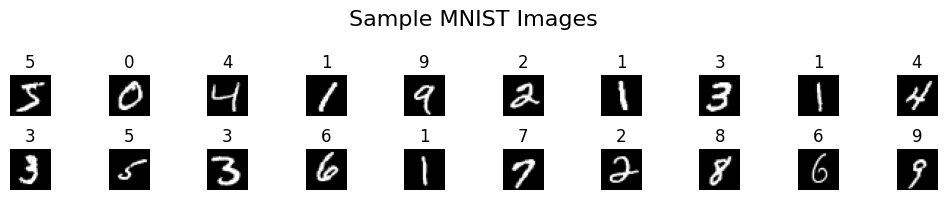

In [ ]:
# traning of mnist dataset is done by using dataloader
train_loader = DataLoader(train_dataset,batch_size=64,shuffle = True)  # dataloader is powerful utility that helps in efficiently loading data in batches , softing data , handling parallism 
test_loader = DataLoader(test_dataset,batch_size=1000,shuffle = False)
# train ;oader is for training dataset 64 means model will process 64 images at once before updating weights
# shuffle btata hai ki model use diffrent data in each epoch
# test loader is used to test dataset

#-----------------EDA = show image samples-----
def show_samples(dataset, n=20):  # we define a small function that displays first 20 images from traning set along with their actual digit labels
    plt.figure(figsize=(10,2))
    for i in range(n):
        image , label  = dataset[i]
        plt.subplot(2,n//2,i+1)
        plt.imshow(image.squeeze(),cmap='gray')
        plt.title(label)
        plt.axis('off') 
    plt.suptitle("Sample MNIST Images",fontsize = 16)
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

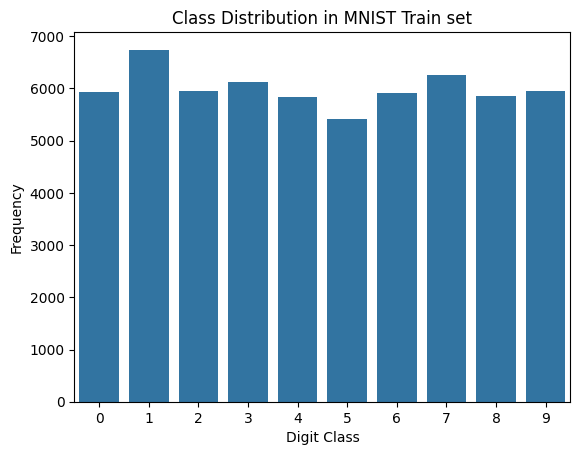

In [ ]:
# -------EDA: Check class distribution----analyze how digits are distriuted in training set
labels = [label for _, label in train_dataset]
sns.countplot(x=labels) # we extract the data from traning dataset and use countplt to visualize how many samples for each digit class from 0 to 9
plt.title("Class Distribution in MNIST Train set")
plt.xlabel("Digit Class")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#---------CNN modek definetion-----
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding = 1)  # it is convolutional layer define as conv1 takes 1 input channel with 16 filters of dimension 3x3   we add padding to ensure output size remain same as input
        self.pool = nn.MaxPool2d(2,2)  # it reduces the size of feature map 2x2 pooling halfs the height and weight
        self.conv2 = nn.Conv2d(16,32,3,padding = 1)  # second convolutuinal layer which takes 16 output channel from previous layer and apply 32 filters of 3x3 dimension
        self.fc1 = nn.Linear(32 * 7 * 7,128)  # we flatten the feature map and its time it to pass them through a fully connected layer with 128 neurons
        self.fc2 = nn.Linear(128,10)  # finally we have our output layer a fully connected layer with neuromns one for each digits from 0 to 9


    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNNModel()
         
         

    

In [ ]:
#-----------loss and optimizer------------
criterion = nn.CrossEntropyLoss()  # Losss function
optimizer = optim.Adam(model.parameters(),lr = 0.001)  # optimizers it adjust the learning rate for each parameter individually making it faster and more efficient during traning   this learning rate definrs how big step the optimizer takes while updating weights in each iteration


In [ ]:
#------------Traning loop---------
epochs = 5  # number of times the model will go throufh training
train_losses = []

for epoch in range(epochs):
    model.train()  # this ensures that certain layers like dropout and batch normalization if present behved appropriately during traning
    running_loss = 0.0
    for images , labels in train_loader:
        optimizer.zero_grad()   # to reset the gradients from previous step
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step() # that updates the model weight using those gradients
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch + 1} / {epochs}],Loss: {avg_loss:.4f}")
        
    

Epoch [1 / 5],Loss: 0.1774
Epoch [2 / 5],Loss: 0.0514
Epoch [3 / 5],Loss: 0.0361
Epoch [4 / 5],Loss: 0.0274
Epoch [5 / 5],Loss: 0.0229


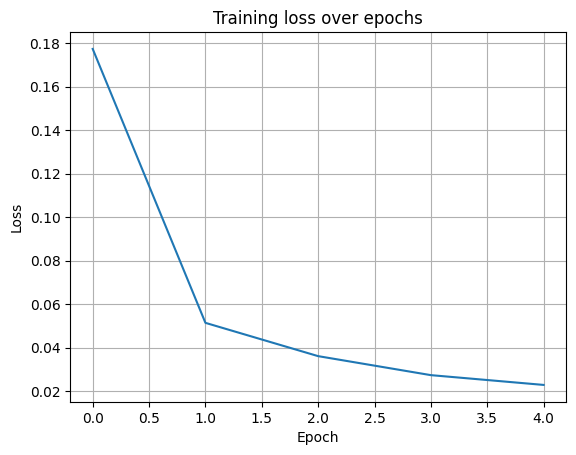

In [ ]:
# ----Plot traning loss---
plt.plot(train_losses)
plt.title("Training loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
#---------Evaluation----------
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images , labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())


#acccuracy and classification report

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))





Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.97      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



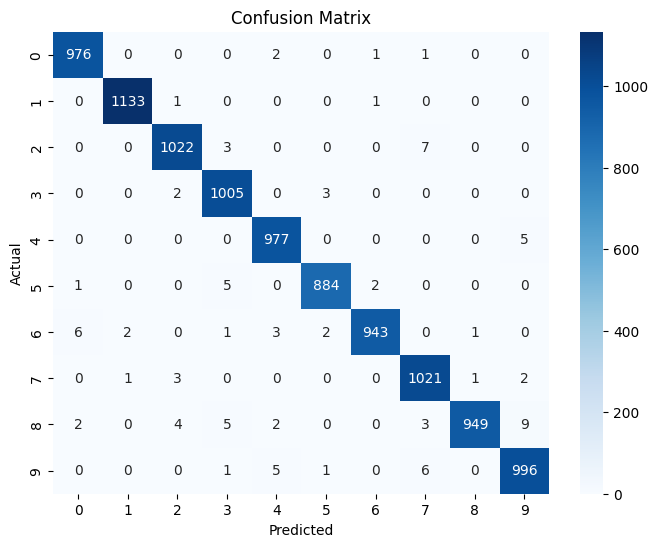

In [ ]:
# Confusion matrix   gives us a detailed breakdownof models predictioncompared to actual labels

conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot=True, fmt = 'd' , cmap = "Blues", xticklabels = range(10), yticklabels = range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


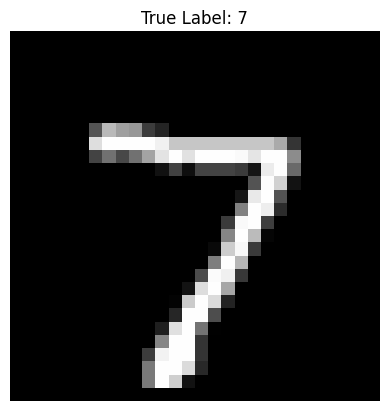

NameError: name 'sample_tensor' is not defined

In [ ]:
#------------Interferwnce on one image------   now we test our model on single image
sample_img, sample_label = test_dataset[0]
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {sample_label}")
plt.axis('off')
plt.show()

sample_tensor = sample_img.unsqueeze(0)   #  the title of image is true level that so that we can later compare it to models prediction
# since our model expects a batch of images we need to add a extra dimension to convert single image into batc of size one using squeeze command
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output).item()
    print(f"Predicted Class: {predicted_class}")